In [2]:
from netCDF4 import Dataset
from matplotlib import pyplot as plt
import numpy as np
import datetime
from scipy.interpolate import griddata
from mpl_toolkits.basemap import Basemap
import os

In [3]:
start_time_era5 = datetime.datetime(1900, 1, 1, 0, 0, 0)
lon_min_era5, lon_max_era5, lat_min_era5, lat_max_era5 = 80, 200, 68, 83

file = '/mnt/hippocamp/DATA/ERA5/w10/era5_uv10m_2020-09.nc'
data = Dataset(file, 'r')

longitude = np.array(data.variables['longitude'][lon_min_era5*4:lon_max_era5*4+1])
latitude = np.array(data.variables['latitude'][(90-lat_max_era5)*4:(90-lat_min_era5)*4+1])
lon_grid, lat_grid = np.meshgrid(longitude, latitude)

In [4]:
def get_era5_data(year, month):
    file = f'/mnt/hippocamp/DATA/ERA5/w10/era5_uv10m_{year}-{month:02}.nc'
    data = Dataset(file, 'r')
    u10 = np.array(data.variables['u10'][:,(90-lat_max_era5)*4:(90-lat_min_era5)*4+1,lon_min_era5*4:lon_max_era5*4+1])
    v10 = np.array(data.variables['v10'][:,(90-lat_max_era5)*4:(90-lat_min_era5)*4+1,lon_min_era5*4:lon_max_era5*4+1])
    
    list_u10 = np.split(u10, u10.shape[0]/24, axis=0)
    array_u10 = np.array([np.mean(a, axis=0) for a in list_u10])
    
    list_v10 = np.split(v10, v10.shape[0]/24, axis=0)
    array_v10 = np.array([np.mean(a, axis=0) for a in list_v10])
    
    time = np.array(data.variables['time'])
    
    return time, array_u10, array_v10

In [5]:
def drawing(u, v, t, lon = lon_grid, lat = lat_grid):
    fig = plt.figure(figsize=(12, 12), dpi=300)
    
    # m = Basemap(width=2600000,height=1500000,
    #             resolution='l',projection='aea',
    #             lat_1=60, lat_2=65, lon_0=72, lat_0=76)
    
    m = Basemap(width=3500000,height=1500000,
                resolution='l',projection='aea',
                lat_1=60, lat_2=65, lon_0=140, lat_0=76)
    
    m.drawcoastlines()
    m.fillcontinents(color='grey', lake_color='white')
    m.drawparallels(np.arange(-80., 90., 2.), labels=[False, True, True, False])
    m.drawmeridians(np.arange(-180., 180., 5.), labels=[True, True, False, True], latmax=90)
    m.drawmapboundary(fill_color='white')
    
    # Преобразование координат для карты
    x, y = m(lon, lat)
    
    # Вычисление скорости ветра
    speed = np.sqrt(u**2 + v**2)
    
    # Отображение скорости ветра
    speed_plot = m.pcolormesh(x, y, speed, shading='gouraud', cmap='jet', vmin=0, vmax=6)
    cbar=plt.colorbar(speed_plot, label='Wind speed (m/s)', shrink=0.50, pad=0.07)
    cbar.set_ticks([0,1,2,3,4,5,6])
    
    # Отображение направления ветра
    m.quiver(x[::4, ::4], y[::4, ::4], u[::4, ::4], v[::4, ::4], scale=30, scale_units='inches')
    plt.title(f'Wind speed {t.date()}')
    
    plt.show()
    plt.close('all')

In [6]:
def make_month(year, month, mean_by):
    time, array_u10, array_v10 = get_era5_data(year, month)
    print(time.shape, array_u10.shape, array_v10.shape)
    
    if mean_by == 'month':
        u10 = array_u10.mean(axis=0)
        v10 = array_v10.mean(axis=0)
        t = start_time_era5 + datetime.timedelta(hours=int(time[0]))

        drawing(u10, v10, t)

    else:
        for i in range(array_u10.shape[0]):
            u10, v10 = array_u10[i], array_v10[i]
            t = start_time_era5 + datetime.timedelta(hours=int(time[24*(i)]))
            
            drawing(u10, v10, t)

In [8]:
year = 2015
months = [7,8,9]

/tmp/ipykernel_11798/369087186.py:13: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  time = np.array(data.variables['time'])


(744,) (31, 61, 481) (31, 61, 481)


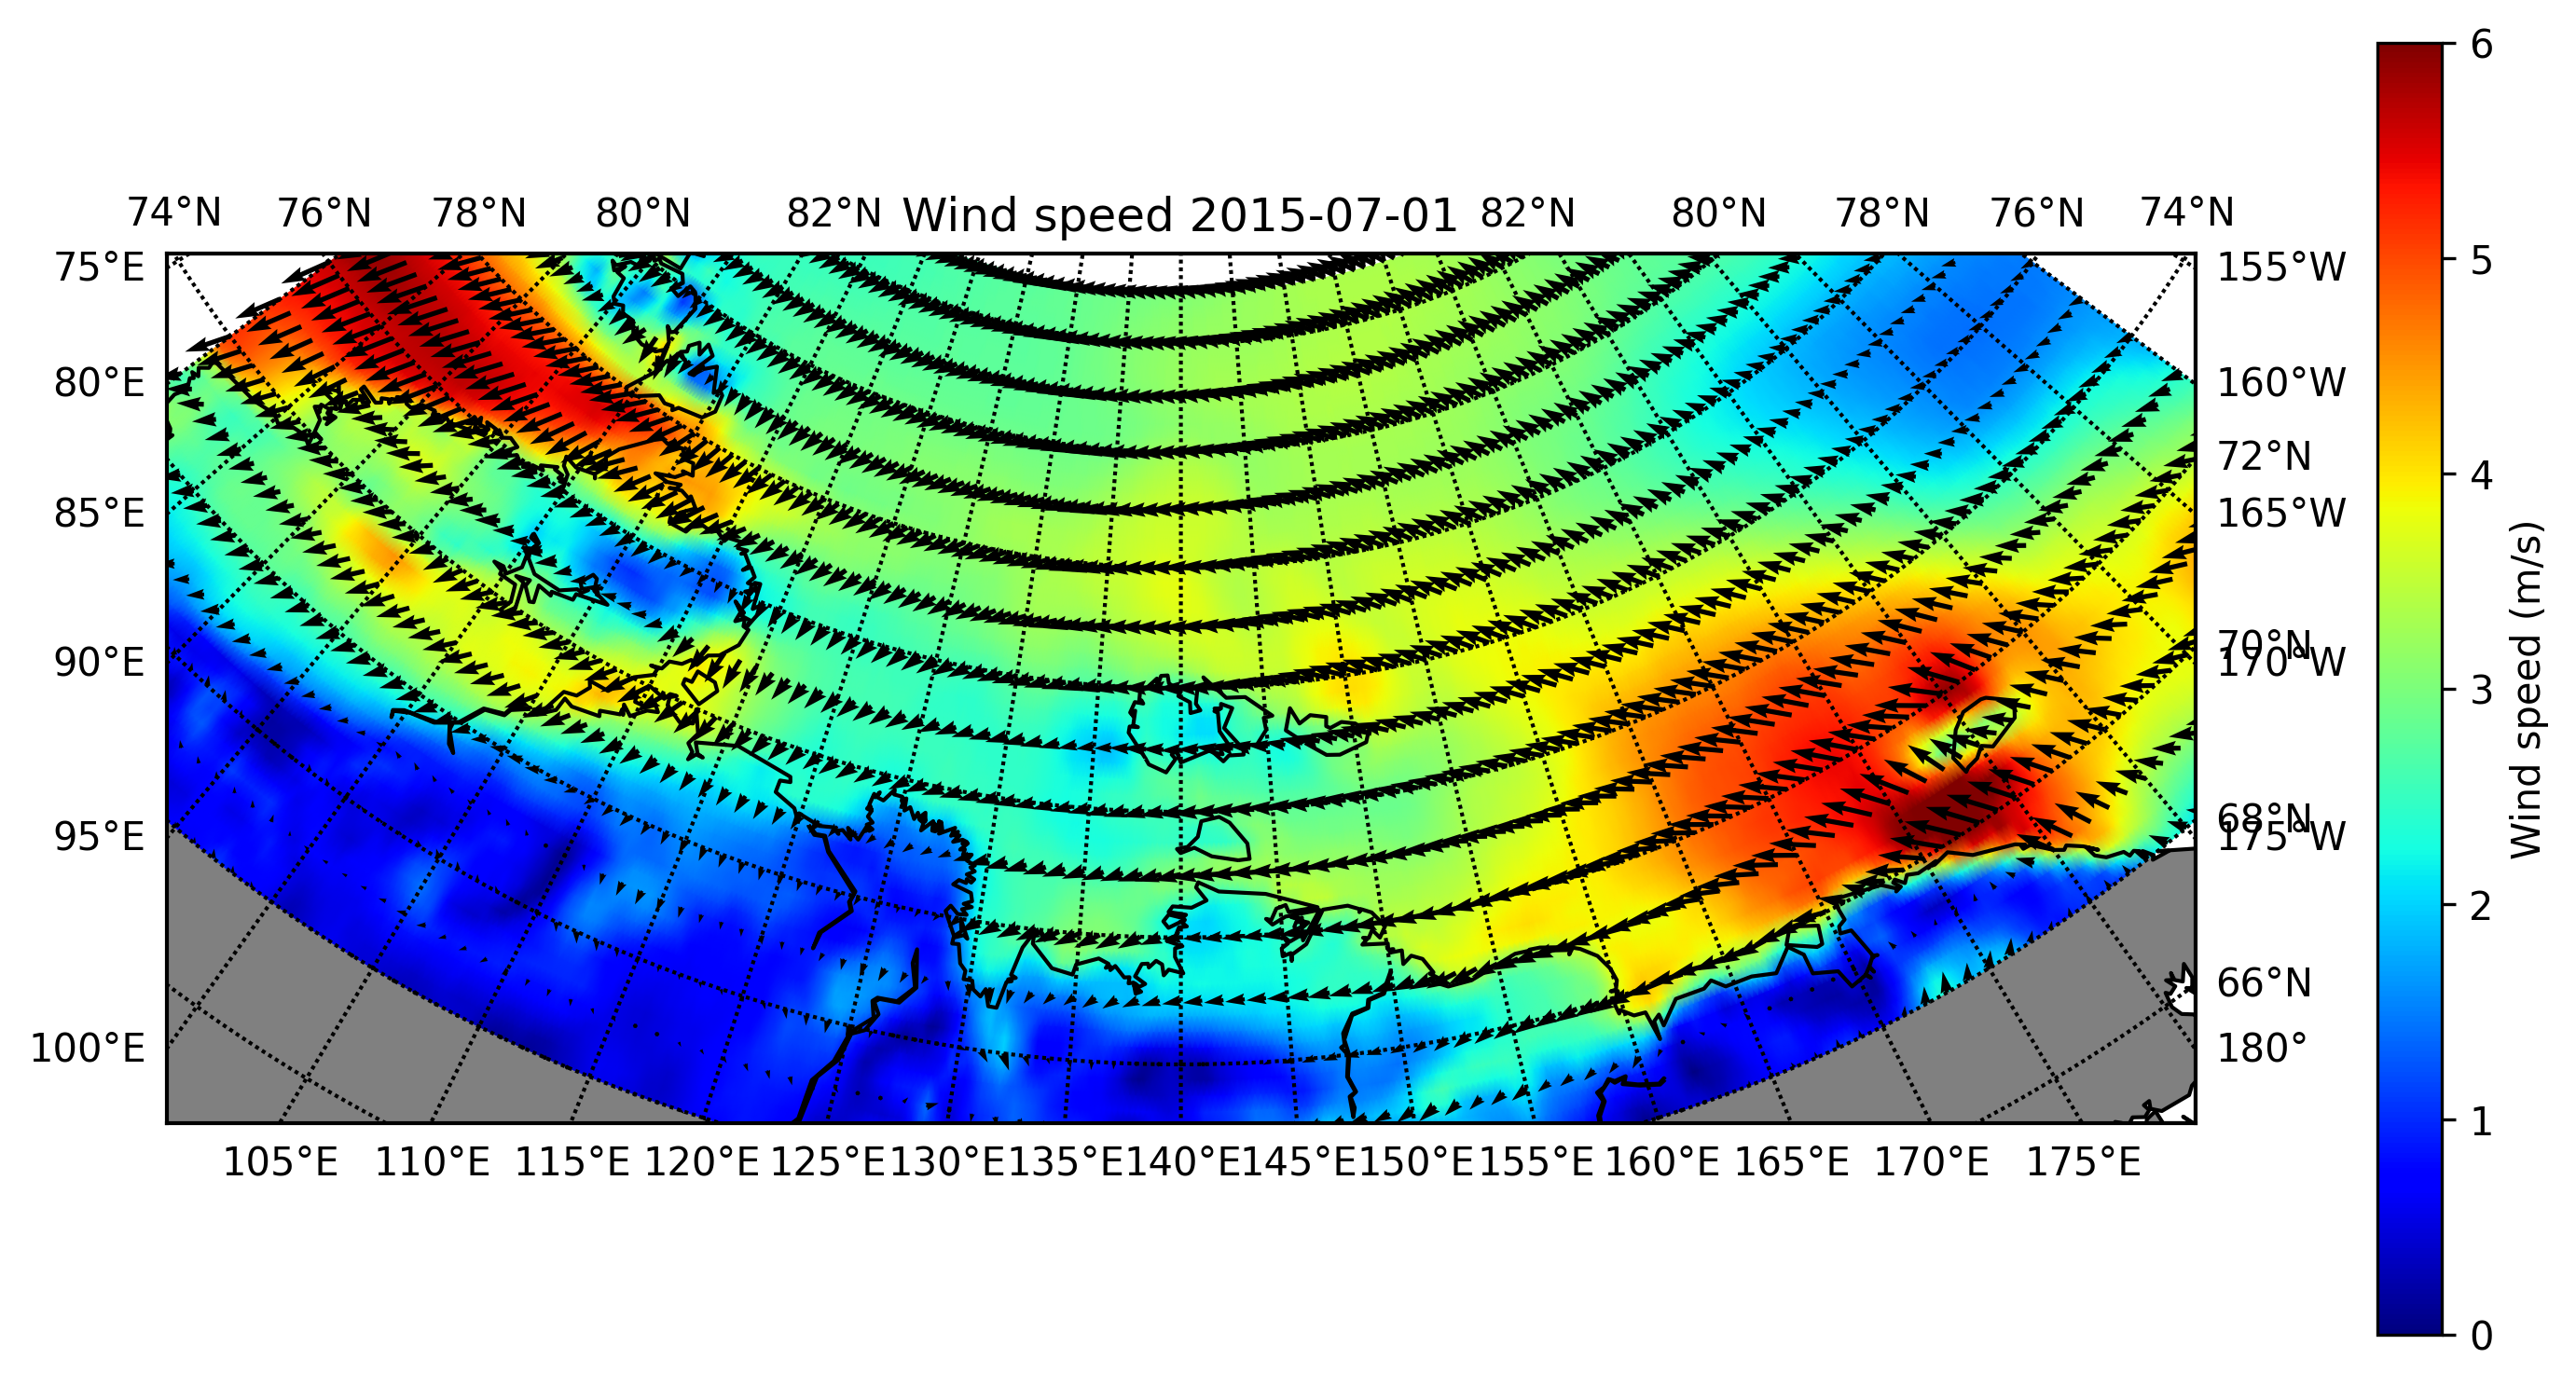

/tmp/ipykernel_11798/369087186.py:13: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  time = np.array(data.variables['time'])


(744,) (31, 61, 481) (31, 61, 481)


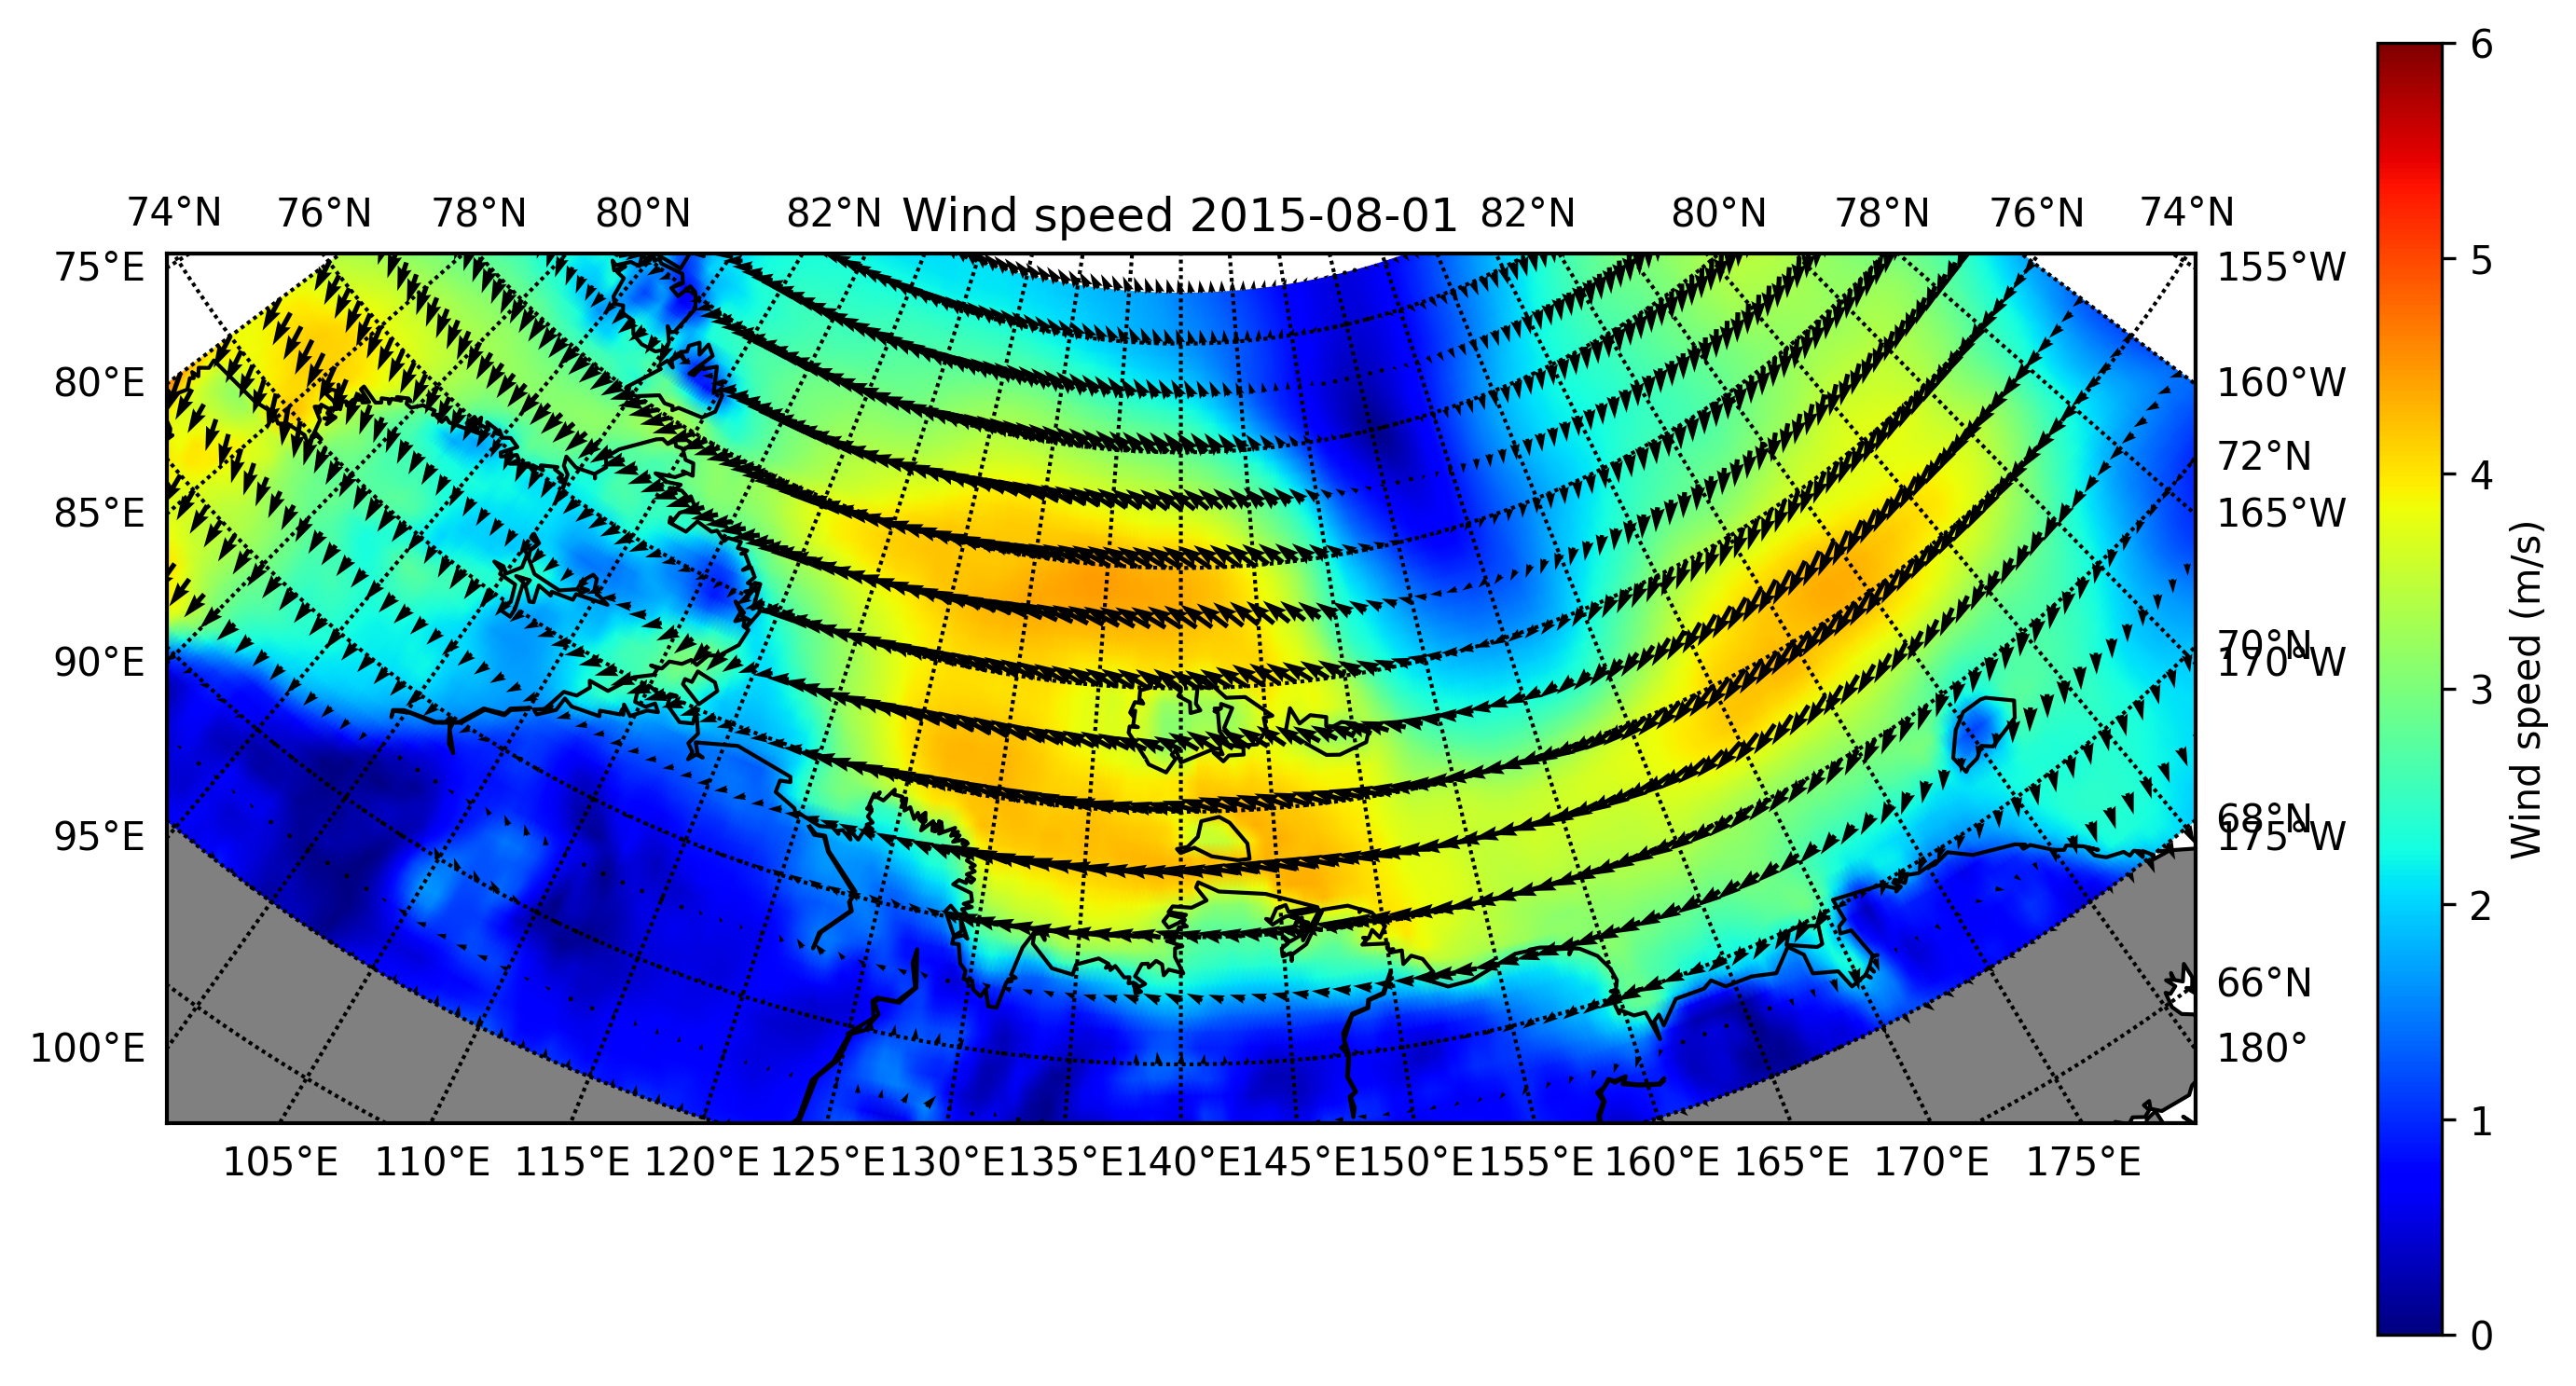

/tmp/ipykernel_11798/369087186.py:13: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  time = np.array(data.variables['time'])


(720,) (30, 61, 481) (30, 61, 481)


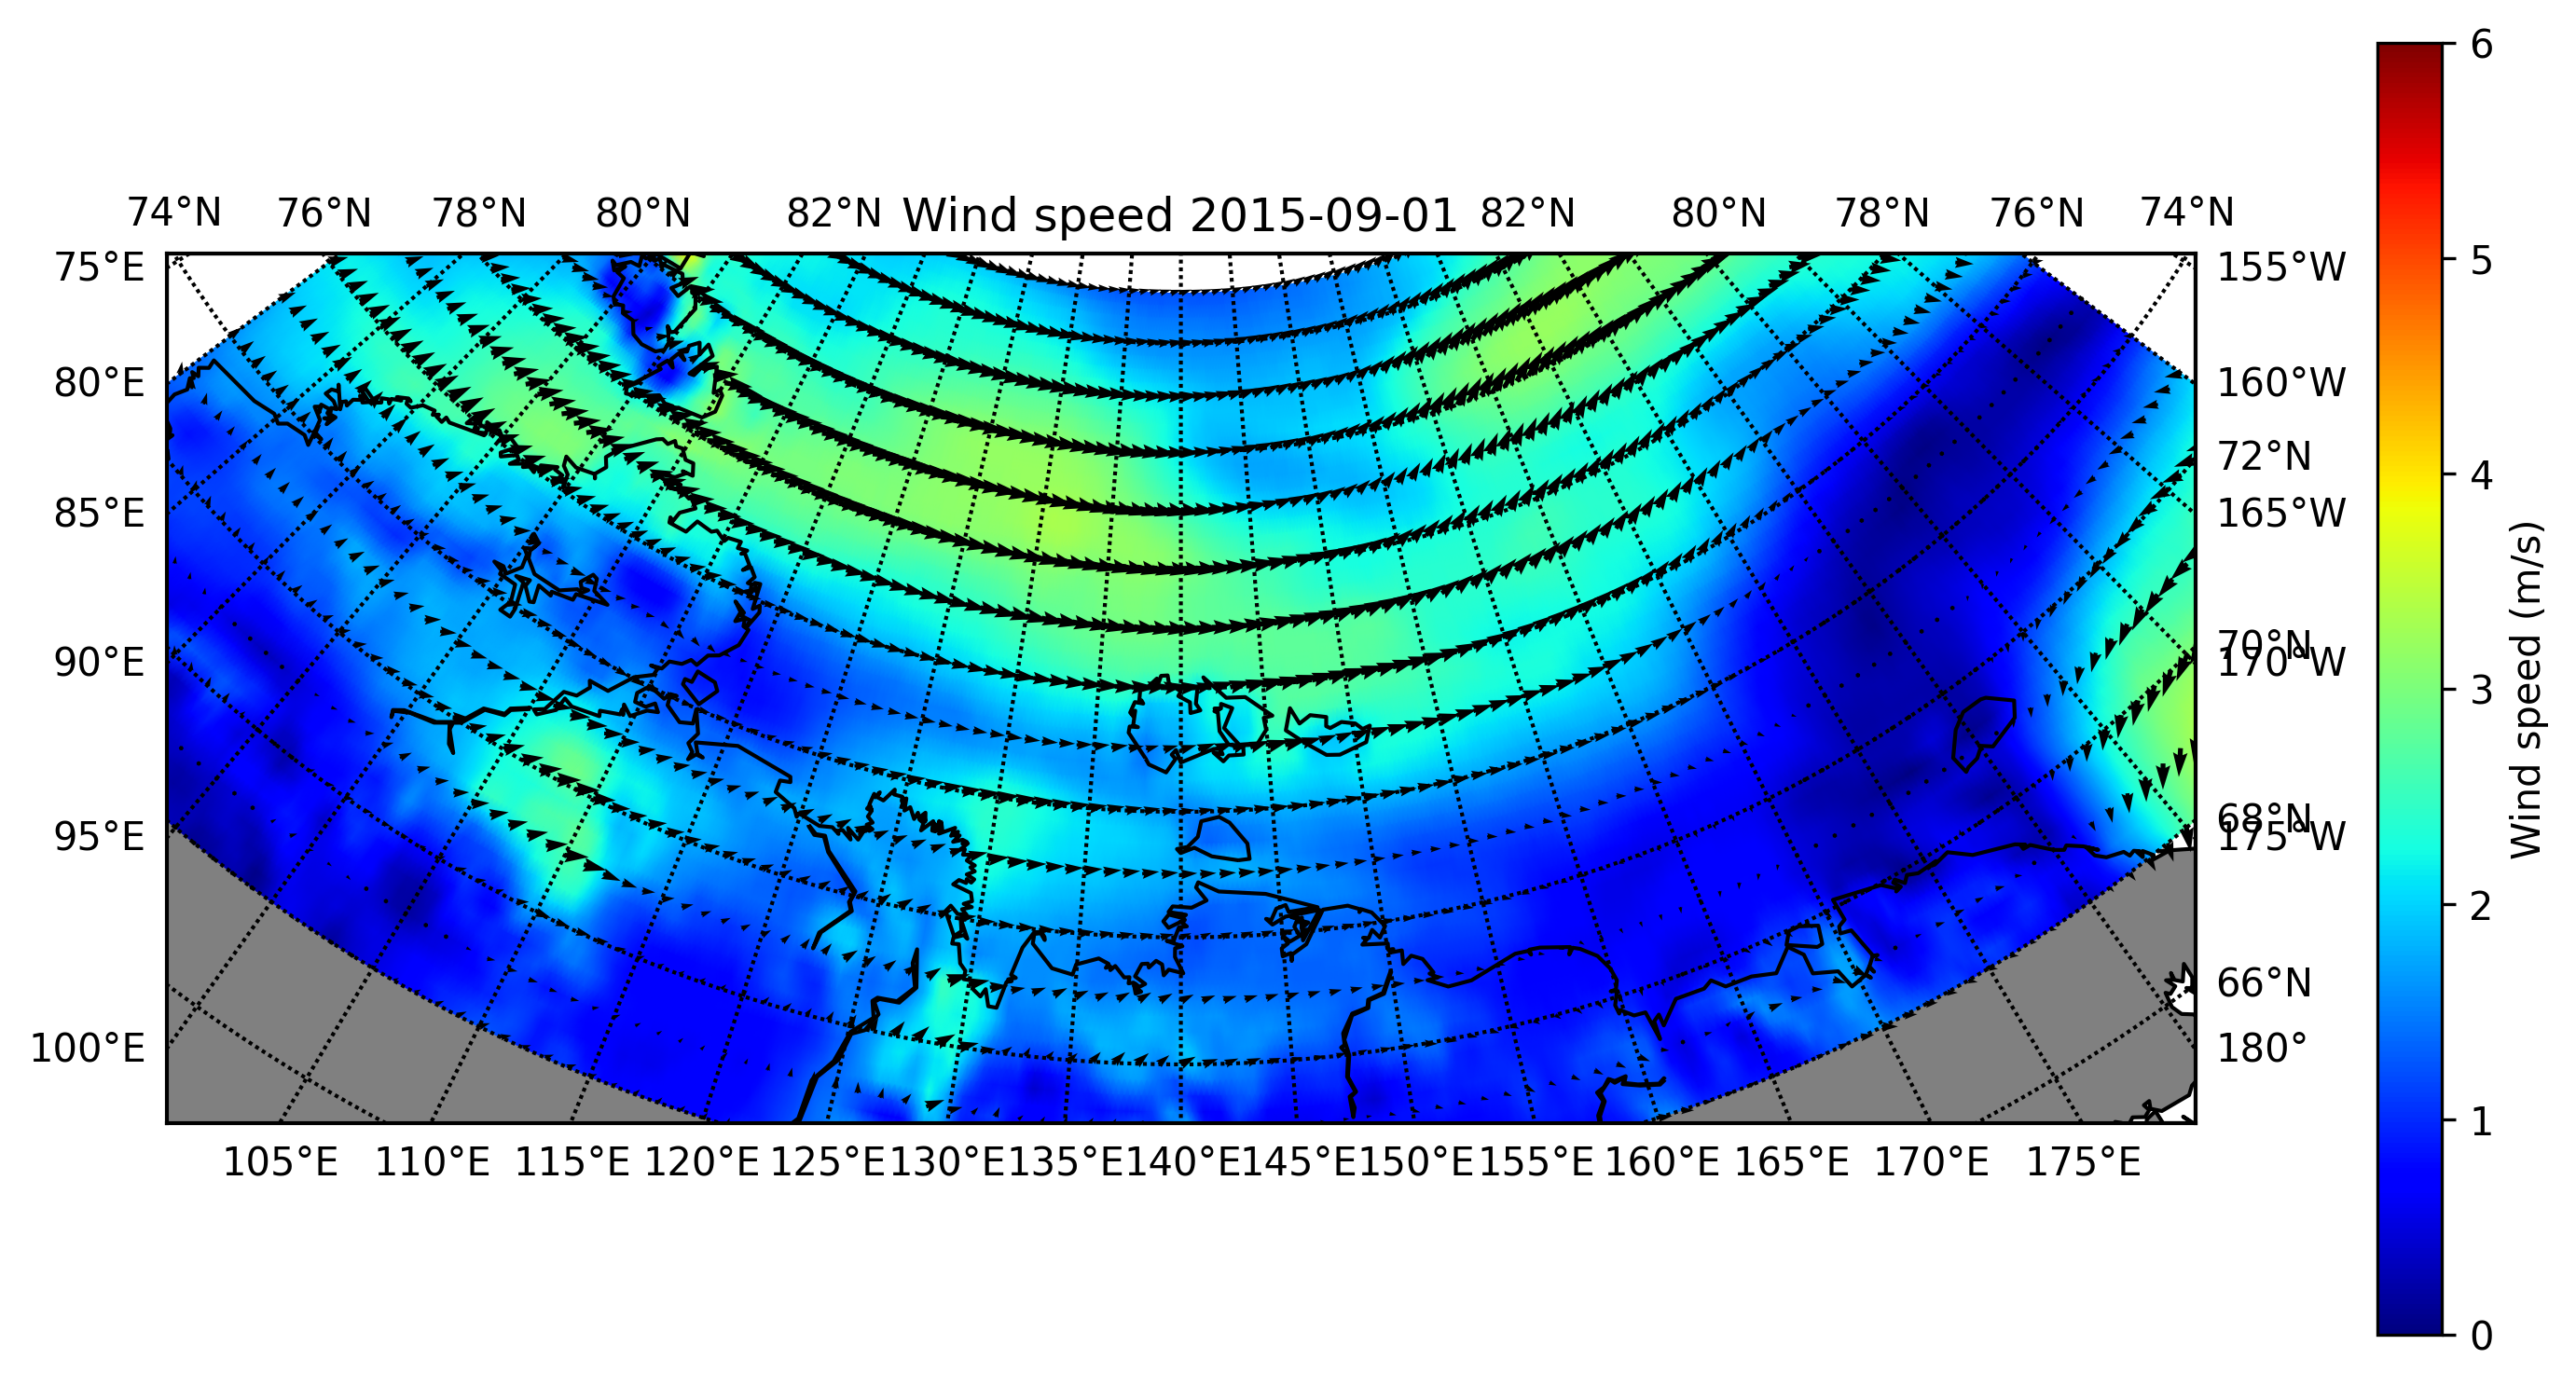

In [9]:
for month in months:
    make_month(year, month, mean_by='month')